
**Project 1: Supermarket Sales Analysis ⭐ (Recommended)
Dataset
Supermarket Sales Dataset (Kaggle)**

**Problem Statement:
Analyze supermarket sales data to identify sales trends, customer behavior, and profitable product categories.**


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("SuperMarket Analysis.csv")
print(df.head())
print(df.info())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

In [40]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# 1. WHICH BRANCH HAS THE HIGHEST SALES?

branch_sales = df.groupby('Branch')['Sales'].sum()

highest_sales_branch = branch_sales.idxmax()
highest_branch_sales = branch_sales.max()

print("1. Highest Sales Branch:", highest_sales_branch)
print("   Total Sales:", highest_branch_sales)


# 2. WHICH PRODUCT LINE IS MOST PROFITABLE?

product_profit = df.groupby('Product line')['gross income'].sum()

most_profitable_product = product_profit.idxmax()
highest_profit = product_profit.max()

print("\n2. Most Profitable Product Line:",
      most_profitable_product)
print("   Total Gross Income:", highest_profit)



# 3. WHICH PAYMENT METHOD IS MOST POPULAR?

payment_count = df['Payment'].value_counts()

most_popular_payment = payment_count.idxmax()
highest_payment_count = payment_count.max()

print("\n3. Most Popular Payment Method:",
      most_popular_payment)
print("   Number of Transactions:",
      highest_payment_count)


# 4. WHICH MONTH HAS MAXIMUM SALES?

# Extract month
df['Month'] = df['Date'].dt.month_name()

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

highest_sales_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

print("\n4. Highest Sales Month:",
      highest_sales_month)
print("   Total Sales:", highest_month_sales)



# 5. WHICH DAY HAS MAXIMUM SALES?

# Extract day name
df['Day'] = df['Date'].dt.day_name()

# Calculate sales by day
daily_sales = df.groupby('Day')['Sales'].sum()

highest_sales_day = daily_sales.idxmax()
highest_day_sales = daily_sales.max()

print("\n5. Highest Sales Day:",
      highest_sales_day)
print("   Total Sales:", highest_day_sales)

1. Highest Sales Branch: Giza
   Total Sales: 110568.7065

2. Most Profitable Product Line: Food and beverages
   Total Gross Income: 2673.564

3. Most Popular Payment Method: Ewallet
   Number of Transactions: 345

4. Highest Sales Month: January
   Total Sales: 116291.868

5. Highest Sales Day: Saturday
   Total Sales: 56120.8095


In [4]:
#remove duplicates
df=df.drop_duplicates()
print("Duplicates row:",df.duplicated().sum())

Duplicates row: 0


In [5]:
#missing values
print(df.isnull().sum())

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


No missing values exists

In [6]:
#convert date columns
df['Date']=pd.to_datetime(df['Date'])
print(df['Date'])

0     2019-01-05
1     2019-03-08
2     2019-03-03
3     2019-01-27
4     2019-02-08
         ...    
995   2019-01-29
996   2019-03-02
997   2019-02-09
998   2019-02-22
999   2019-02-18
Name: Date, Length: 1000, dtype: datetime64[ns]


In [7]:
#correct data types
print(df.dtypes)

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object


In [8]:
df['Rating']=pd.to_numeric(df['Rating'])
df['Unit price']=pd.to_numeric(df['Unit price'])
print(df['Rating'].dtypes)
print(df['Unit price'].dtypes)

float64
float64


In [12]:
#analysis
#Total sales
total_sales=df['Sales'].sum()
print("Total sales:",total_sales)

Total sales: 322966.749


In [14]:
#avg sales
avg_sales=df['Sales'].mean()
print("avg sales:",avg_sales)

avg sales: 322.966749


In [15]:
#groupby branch
branch_sales=df.groupby('Branch')['Sales'].sum().sort_values(ascending=False)
print(branch_sales)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


In [17]:
#groupby product
product_sales=df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


In [21]:
#monthly sales trend
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month_name()
monthly_sales=df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
February     97219.374
January     116291.868
March       109455.507
Name: Sales, dtype: float64


In [22]:
import sqlite3

# 1. Read the CSV file
df = pd.read_csv("SuperMarket Analysis.csv")

# 2. Create a SQLite database
connection = sqlite3.connect("supermarket.db")

# 3. Convert CSV data into a SQL table
df.to_sql(
    "supermarket_sales",
    connection,
    if_exists="replace",
    index=False
)

print("CSV data successfully converted into SQL table!")
connection.close()

CSV data successfully converted into SQL table!


In [32]:
connection = sqlite3.connect("supermarket.db")

query = """
SELECT SUM(Sales) AS Total_Revenue
FROM supermarket_sales
"""

result = pd.read_sql_query(query, connection)

print(result)

connection.close()




   Total_Revenue
0     322966.749


In [31]:
#top selling product line
connection = sqlite3.connect("supermarket.db")

query2 = """
SELECT
    "Product line",
    SUM(Sales) AS Total_Sales
FROM supermarket_sales
GROUP BY "Product line"
ORDER BY Total_Sales DESC;
"""

result2 = pd.read_sql_query(query2, connection)

print(result2)
connection.close()

             Product line  Total_Sales
0      Food and beverages   56144.8440
1       Sports and travel   55122.8265
2  Electronic accessories   54337.5315
3     Fashion accessories   54305.8950
4      Home and lifestyle   53861.9130
5       Health and beauty   49193.7390


In [30]:
connection = sqlite3.connect("supermarket.db")
#highest sales branch
query3 = """
SELECT
    Branch,
    SUM(Sales) AS Total_Sales
FROM supermarket_sales
GROUP BY Branch
ORDER BY Total_Sales DESC
LIMIT 1;
"""

result3 = pd.read_sql_query(query3, connection)

print(result3)
connection.close()

  Branch  Total_Sales
0   Giza  110568.7065


In [33]:
connection = sqlite3.connect("supermarket.db")
#avg customer rating
query4 = """
SELECT AVG(Rating) AS Average_Customer_Rating
FROM supermarket_sales;
"""

result4 = pd.read_sql_query(query4, connection)

print(result4)
connection.close()

   Average_Customer_Rating
0                   6.9727


In [34]:
connection=sqlite3.connect("supermarket.db")
#total sales by city
query5= """
SELECT AVG(Rating) AS Average_Customer_Rating
FROM supermarket_sales;
"""

result5 = pd.read_sql_query(query5, connection)

print(result5)

   Average_Customer_Rating
0                   6.9727


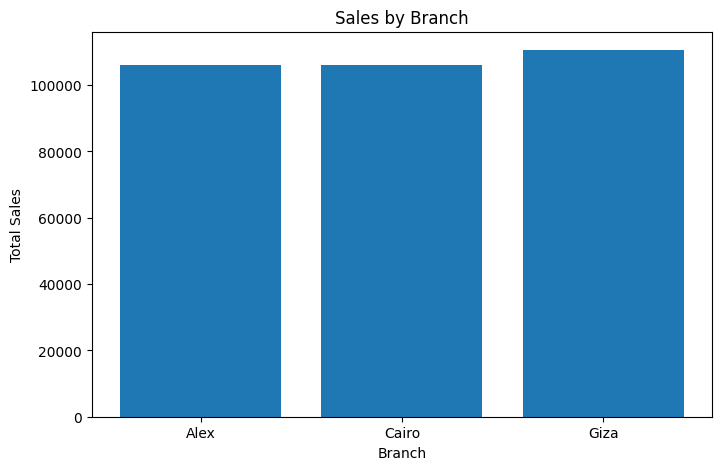

In [35]:
#CHARTS
import matplotlib.pyplot as plt
df=pd.read_csv('SuperMarket Analysis.csv')


branch_sales = df.groupby('Branch')['Sales'].sum()

# Create Bar Chart
plt.figure(figsize=(8, 5))

plt.bar(
    branch_sales.index,
    branch_sales.values
)

plt.title('Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')

plt.show()

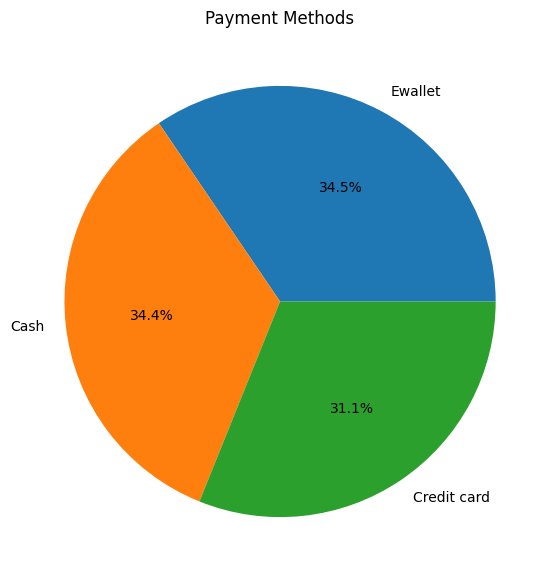

In [36]:
payment_counts = df['Payment'].value_counts()

# Create Pie Chart
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Payment Methods')

plt.show()

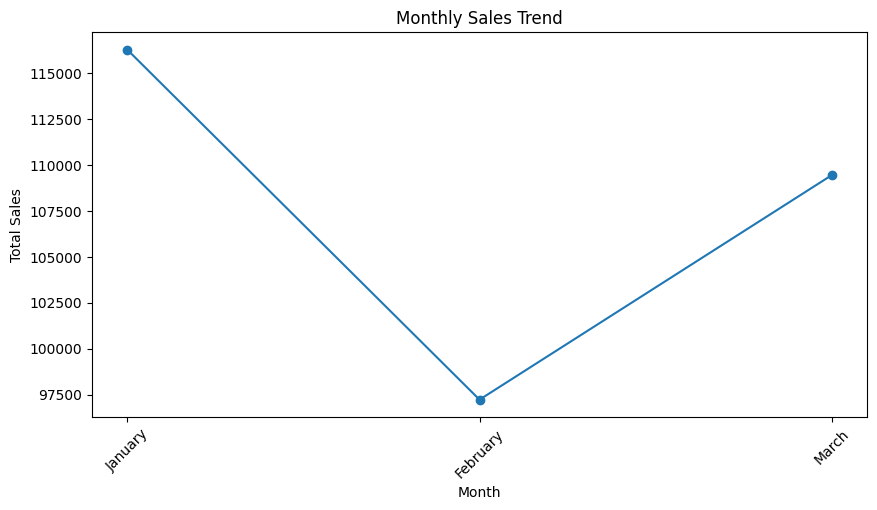

In [37]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month_name()

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

# Arrange months in correct order
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_sales = monthly_sales.reindex(
    [month for month in month_order if month in monthly_sales.index]
)

# Create Line Chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

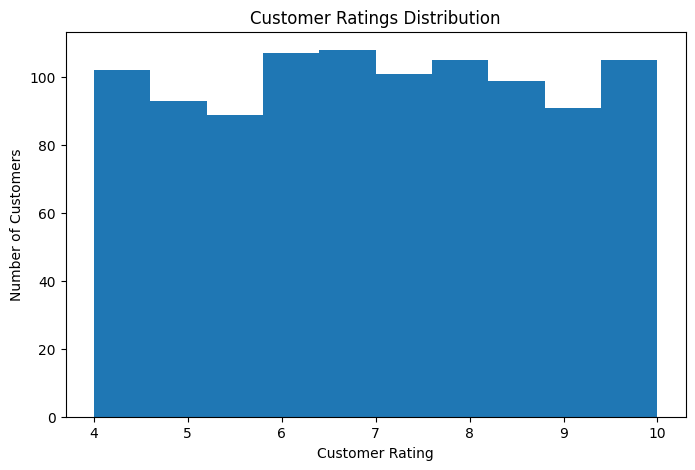

In [38]:
# Create Histogram
plt.figure(figsize=(8, 5))

plt.hist(
    df['Rating'],
    bins=10
)

plt.title('Customer Ratings Distribution')
plt.xlabel('Customer Rating')
plt.ylabel('Number of Customers')

plt.show()

In [39]:
df = pd.read_csv("SuperMarket Analysis.csv")

# : TOTAL REVENUE

total_revenue = df['Sales'].sum()
#  TOTAL CUSTOMERS

# Count unique Invoice IDs
total_customers = df['Invoice ID'].nunique()

#  BEST BRANCH

branch_sales = df.groupby('Branch')['Sales'].sum()

best_branch = branch_sales.idxmax()
best_branch_sales = branch_sales.max()

# BEST PRODUCT


product_sales = df.groupby('Product line')['Sales'].sum()

best_product = product_sales.idxmax()
best_product_sales = product_sales.max()


#  HIGHEST REVENUE MONTH

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month_name()

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

highest_revenue_month = monthly_sales.idxmax()
highest_month_revenue = monthly_sales.max()


# =========================================
# DISPLAY DASHBOARD SUMMARY
# =========================================

print("=" * 45)
print("       SUPERMARKET SALES DASHBOARD")
print("=" * 45)

print("Total Revenue          :", round(total_revenue, 2))

print("Total Customers        :", total_customers)

print("Best Branch             :", best_branch)
print("Best Branch Sales      :", round(best_branch_sales, 2))

print("Best Product            :", best_product)
print("Best Product Sales     :", round(best_product_sales, 2))

print("Highest Revenue Month  :", highest_revenue_month)
print("Highest Monthly Revenue:", round(highest_month_revenue, 2))

print("=" * 45)

       SUPERMARKET SALES DASHBOARD
Total Revenue          : 322966.75
Total Customers        : 1000
Best Branch             : Giza
Best Branch Sales      : 110568.71
Best Product            : Food and beverages
Best Product Sales     : 56144.84
Highest Revenue Month  : January
Highest Monthly Revenue: 116291.87


**Recommendations**

**Based on the analysis, the supermarket can:**

1.Study the strategies of the highest-performing branch and apply successful practices to other branches.

2.Promote the most profitable product lines to increase overall profit.

3.Maintain sufficient inventory for high-demand products.

4.Plan special promotions during months with lower sales.

5.Focus marketing campaigns on popular payment methods while continuing to provide multiple payment options.

6.Monitor customer ratings and improve service quality where necessary.

7.Use customer purchase patterns to create personalized promotions.

8.Analyze low-performing branches and product lines to identify opportunities for improvement.